In [1]:
import time
import copy
import matplotlib.pyplot as plt
import math
import numpy as np
import pandas as pd
import torch
from matplotlib.lines import Line2D
from genkit import GaussianFlowLinear
from genkit.metrics import mssle_95, wasserstein_distance
from genkit._sampling import sample_gaussian, sample_scaled_isotropic_alpha_stable
from genkit.datasets import fetch_synthetic_data
from genkit.nn import MLPModel
from genkit.training import train
from genkit.visitor import CoreMetricsVisitor
from genkit.plotting import PRETTY_RCPARAMS


plt.rcParams.update(PRETTY_RCPARAMS)

In [ ]:
def barron_loss(
    pred: torch.Tensor,
    target: torch.Tensor,
    alpha: float | torch.Tensor = 1.0,
    scale: float | torch.Tensor = 1.0,
    reduction: str = "mean",
    eps: float = 1e-12,
) -> torch.Tensor:
    """
    Barron robust loss (A General and Adaptive Robust Loss Function, Eq. 8).

    rho(x, alpha, c) =
        0.5 * (x / c)^2                                 if alpha == 2
        log(0.5 * (x / c)^2 + 1)                        if alpha == 0
        1 - exp(-0.5 * (x / c)^2)                       if alpha == -inf
        |alpha-2|/alpha * (((x/c)^2 / |alpha-2| + 1)^(alpha/2) - 1)  otherwise
    """
    if reduction not in {"none", "mean", "sum"}:
        raise ValueError(f"Invalid reduction: {reduction}")

    x = pred - target
    dtype = x.dtype
    device = x.device

    alpha = torch.as_tensor(alpha, dtype=dtype, device=device)
    scale = torch.as_tensor(scale, dtype=dtype, device=device).clamp_min(eps)

    z = (x / scale) ** 2

    loss_two = 0.5 * z
    loss_zero = torch.log1p(0.5 * z)
    loss_neginf = -torch.expm1(-0.5 * z)

    beta = torch.abs(alpha - 2.0).clamp_min(eps)
    loss_general = (beta / alpha) * (torch.pow(z / beta + 1.0, 0.5 * alpha) - 1.0)

    if alpha.ndim == 0:
        a = float(alpha.item())
        if math.isinf(a) and a < 0:
            loss = loss_neginf
        elif abs(a - 2.0) < 1e-6:
            loss = loss_two
        elif abs(a) < 1e-6:
            loss = loss_zero
        else:
            loss = loss_general
    else:
        is_two = torch.isclose(alpha, torch.tensor(2.0, dtype=dtype, device=device), atol=1e-6, rtol=0.0)
        is_zero = torch.isclose(alpha, torch.tensor(0.0, dtype=dtype, device=device), atol=1e-6, rtol=0.0)
        is_neginf = torch.isneginf(alpha)

        loss = torch.where(is_two, loss_two, loss_general)
        loss = torch.where(is_zero, loss_zero, loss)
        loss = torch.where(is_neginf, loss_neginf, loss)

    if reduction == "mean":
        return loss.mean()
    if reduction == "sum":
        return loss.sum()
    return loss


class AlphaStableSourceMixin:
    def __init__(self, *args, source_alpha: float = 1.5, **kwargs):
        super().__init__(*args, **kwargs)
        self._source_alpha = float(source_alpha)

    def _sample_source_default(self, n_samples: int) -> torch.Tensor:
        return sample_scaled_isotropic_alpha_stable(
            n_samples=n_samples,
            dim=self._dim,
            alpha=self._source_alpha,
            device=self._device,
            dtype=self._fdtype,
        )


class AlphaStableSourceGaussianFlowLinear(AlphaStableSourceMixin, GaussianFlowLinear):
    pass


class PreprocessedTargetMixin:
    def __init__(self, *args, preprocess: str = "asinh", preprocess_scale: float = 1.0, **kwargs):
        super().__init__(*args, **kwargs)
        self._preprocess = str(preprocess)
        self._preprocess_scale = float(preprocess_scale)
        if self._preprocess_scale <= 0:
            raise ValueError(f"preprocess_scale must be > 0, got {self._preprocess_scale}")

    def _transform(self, x: torch.Tensor) -> torch.Tensor:
        scale = torch.as_tensor(self._preprocess_scale, device=x.device, dtype=x.dtype)
        if self._preprocess == "identity":
            return x
        if self._preprocess == "signed_log1p":
            return torch.sign(x) * torch.log1p(torch.abs(x) / scale)
        if self._preprocess == "asinh":
            return torch.asinh(x / scale)
        raise ValueError(f"Unknown preprocess: {self._preprocess}")

    def _inverse_transform(self, y: torch.Tensor) -> torch.Tensor:
        scale = torch.as_tensor(self._preprocess_scale, device=y.device, dtype=y.dtype)
        if self._preprocess == "identity":
            return y
        if self._preprocess == "signed_log1p":
            return torch.sign(y) * scale * torch.expm1(torch.abs(y))
        if self._preprocess == "asinh":
            return scale * torch.sinh(y)
        raise ValueError(f"Unknown preprocess: {self._preprocess}")

    def _precompute_loss(self, x, z, t=None):
        return super()._precompute_loss(x=self._transform(x), z=z, t=t)

    @torch.no_grad()
    def sample(self, n_samples: int) -> torch.Tensor:
        y = super().sample(n_samples)
        return self._inverse_transform(y)


class PreprocessedGaussianFlowLinear(PreprocessedTargetMixin, GaussianFlowLinear):
    pass


class BarronLossMixin:
    def __init__(self, *args, alpha: float = 1.0, **kwargs):
        super().__init__(*args, **kwargs)
        self._alpha = float(alpha)

    def _loss_fn(self, pred: torch.Tensor, target: torch.Tensor, t: int):
        return barron_loss(pred, target, alpha=self._alpha, reduction="none")

    def _reduce(self, loss_values: torch.Tensor) -> torch.Tensor:
        return loss_values.mean()


def fmt_alabel(value: float) -> str:
    value = float(value)
    if value.is_integer():
        return str(int(value))
    return f"{value:g}"


def alpha_tag(value: float) -> str:
    label = fmt_alabel(value)
    return label.replace('-', 'neg').replace('.', 'p')


def preprocess_tag(name: str) -> str:
    return name.replace('-', '_').replace('(', '_').replace(')', '_').replace('/', '_').replace(' ', '_').replace('+', 'plus')


def preprocess_label(preprocess: str, scale: float) -> str:
    if preprocess == "signed_log1p":
        return "signed-log1p(x)" if scale == 1.0 else f"signed-log1p(x / {scale:g})"
    if preprocess == "asinh":
        return "asinh(x)" if scale == 1.0 else f"asinh(x / {scale:g})"
    if preprocess == "identity":
        return "x"
    raise ValueError(f"Unknown preprocess: {preprocess}")


def build_model_specs(source_alpha, barron_alphas, scale=1.0):
    sources = {"Gaussian": (GaussianFlowLinear, {}),
               "Gaussian + asinh(x)": (PreprocessedGaussianFlowLinear, {"scale": scale}),
               "AlphaStable": (AlphaStableSourceGaussianFlowLinear, {"source_alpha": source_alpha}),
               }

    specs = []
    for source_distri, (source_cls, base_kwargs) in sources.items():
        for barron_alpha in barron_alphas:
            name = f"{preprocess_tag(source_distri)}BarronAlpha{alpha_tag(barron_alpha)}"
            spec = {"name": name,
                    "cls": type(name, (BarronLossMixin, source_cls), {}),
                    "source_distri": source_distri,
                    "loss": rf"$\alpha = {barron_alpha}$",
                    "loss_alpha": float(barron_alpha),
                    "extra_kwargs": {**base_kwargs, "alpha": float(barron_alpha)},
                    }

            specs.append(spec)
    return specs


def curve_style(spec, source_colors, loss_ls):
    color = source_colors[spec["source_distri"]]
    linestyle = loss_ls[float(spec["loss_alpha"])]
    return color, linestyle


def averaged_grad_curve(result, n_epochs, n_points=15):
    l_grad_var, l_loss = [], []
    for trial in result["trials"]:
        grad_var = np.asarray(trial["diagnostics"]["visitors"]["core"]["grad_variance_epoch"], dtype=float)
        loss = np.asarray(trial["diagnostics"]["visitors"]["core"]["training_loss"], dtype=float)
        l_grad_var.append(grad_var[::max(1, int(n_epochs / n_points))])
        l_loss.append(loss[::max(1, int(n_epochs / n_points))])
    return np.mean(np.stack(l_loss, axis=0), axis=0), np.mean(np.stack(l_grad_var, axis=0), axis=0)


def to_latex_sci(x: float, digits: int = 1) -> str:
    """Format a float in LaTeX scientific notation."""
    if x == 0:
        return "0"
    exponent = math.floor(math.log10(abs(x)))
    mantissa = x / (10 ** exponent)
    if exponent == 0:
        return f"{x:.{digits}f}"
    return rf"{mantissa:.{digits}f}\;10^{{{exponent}}}"


def format_mean_std_latex(mean: float, std: float, bold: bool = False) -> str:
    mean_str = to_latex_sci(mean, digits=2)
    std_str = to_latex_sci(std, digits=2)
    if bold:
        return rf"$\mathbf{{{mean_str}}}\;\pm\;\mathbf{{{std_str}}}$"
    return rf"${mean_str} \pm {std_str}$"


In [3]:
dim = 10
stable_alpha_data = 1.8
n_samples_train = 30_000
n_samples_test = 5_000

stable_alpha_model = 1.8
target_preprocess = "asinh"
target_preprocess_scale = 1.0
gaussian_preprocess_label = f"Gaussian + {preprocess_label(target_preprocess, target_preprocess_scale)}"
barron_alphas = [2.0, 1.0, 0.0, -10_000.0]
n_steps = 250
batch_size = 1024
n_epochs = 500
lr = 1e-4
depth = 4
width = 64
n_trials = 5
num_workers = 0

source_order = ["Gaussian", gaussian_preprocess_label, "AlphaStable"]
loss_order = [f"$\\alpha = {fmt_alabel(alpha)}$" for alpha in barron_alphas]

device = "cuda" if torch.cuda.is_available() else "cpu"
fdtype = torch.float32
idtype = torch.int32

source_colors = {"Gaussian": "tab:blue",
                 gaussian_preprocess_label: "tab:green",
                 "AlphaStable": "tab:red",
                }

loss_ls = {
    2.0: "solid",
    1.0: "dashed",
    0.0: "dashdot",
    -10_000.0: "dotted",
}


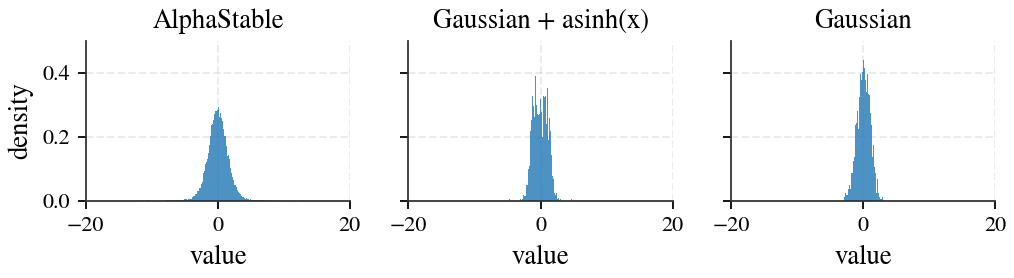

In [4]:
preview_alpha_stable = sample_scaled_isotropic_alpha_stable(n_samples=n_samples_train, dim=1, alpha=stable_alpha_data,
                                                            device="cpu", dtype=torch.float32).squeeze(-1)
if target_preprocess == "asinh":
    preview_transformed = torch.asinh(preview_alpha_stable / target_preprocess_scale)
elif target_preprocess == "signed_log1p":
    preview_transformed = torch.sign(preview_alpha_stable) * torch.log1p(torch.abs(preview_alpha_stable) / target_preprocess_scale)
elif target_preprocess == "identity":
    preview_transformed = preview_alpha_stable
else:
    raise ValueError(f"Unknown preprocess: {target_preprocess}")

preview_samples = {"AlphaStable": preview_alpha_stable.cpu().numpy(),
                   gaussian_preprocess_label: preview_transformed.cpu().numpy(),
                   "Gaussian": sample_gaussian(n_samples=n_samples_train, dim=1, device="cpu", dtype=torch.float32).squeeze(-1).cpu().numpy(),
                   }

fig, axis = plt.subplots(1, len(preview_samples), figsize=(2.2 * len(preview_samples), 2.0), squeeze=False, sharex=False, sharey=True)
for ax, (name, values) in zip(axis.flat, preview_samples.items()):
    ax.hist(values, bins=int(n_samples_train / 20), density=True, alpha=0.8, color="tab:blue", label="hist")
    ax.set_xlim(-20, 20)
    ax.set_ylim(0, 0.5)
    ax.set_title(name)

for ax in axis.flat:
    ax.set_xlabel("value")
axis[0, 0].set_ylabel("density")

fig.tight_layout()


In [5]:
model_specs = build_model_specs(stable_alpha_model, barron_alphas,
                                preprocess=target_preprocess,
                                preprocess_scale=target_preprocess_scale)

x_train, _, x_ref = fetch_synthetic_data("alpha_stable", alpha=stable_alpha_data, n_samples=n_samples_train,
                                         dim=dim, device=device, dtype=fdtype)
x_ref = x_ref[:n_samples_test]

kwargs = dict(target_data=x_train, batch_size=batch_size, n_epochs=n_epochs,
              lr=lr, device=device, num_workers=num_workers)
net_kwargs = dict(width=width, depth=depth)


In [6]:
raw_results = {}
total_runs = len(model_specs) * n_trials
run_idx = 0

for spec in model_specs:
    trials = []
    for trial_idx in range(n_trials):
        run_idx += 1
        extra_kwargs = dict(spec["extra_kwargs"])
        net = MLPModel(dim=dim, **net_kwargs).to(device=device, dtype=fdtype)
        generator = spec["cls"](net=net, dim=dim, n_steps=n_steps, device=device, fdtype=fdtype, idtype=idtype, **extra_kwargs)
        kwargs["generative_model"] = generator
        kwargs["visitors"] = [CoreMetricsVisitor()]

        t0 = time.time()
        print(f"[{run_idx:02d} / {total_runs:02d}] {spec['name']} trial {trial_idx + 1}/{n_trials}: Training...", end="")
        generator, diagnostics = train(**kwargs)
        print(f"Done (in {time.time() - t0:.1f} s).")

        trials.append({
            "generator": generator,
            "diagnostics": diagnostics,
            "extra_kwargs": extra_kwargs,
        })

    raw_results[spec["name"]] = {
        "meta": {k: spec[k] for k in ("name", "source_distri", "loss", "loss_alpha")},
        "trials": trials,
    }


[01 / 60] GaussianBarronAlpha2 trial 1/5: Training...Done (in 179.4 s).
[02 / 60] GaussianBarronAlpha2 trial 2/5: Training...Done (in 178.5 s).
[03 / 60] GaussianBarronAlpha2 trial 3/5: Training...Done (in 180.8 s).
[04 / 60] GaussianBarronAlpha2 trial 4/5: Training...Done (in 205.2 s).
[05 / 60] GaussianBarronAlpha2 trial 5/5: Training...Done (in 243.7 s).
[06 / 60] GaussianBarronAlpha1 trial 1/5: Training...Done (in 223.2 s).
[07 / 60] GaussianBarronAlpha1 trial 2/5: Training...Done (in 201.3 s).
[08 / 60] GaussianBarronAlpha1 trial 3/5: Training...Done (in 191.7 s).
[09 / 60] GaussianBarronAlpha1 trial 4/5: Training...Done (in 201.1 s).
[10 / 60] GaussianBarronAlpha1 trial 5/5: Training...Done (in 204.1 s).
[11 / 60] GaussianBarronAlpha0 trial 1/5: Training...Done (in 188.7 s).
[12 / 60] GaussianBarronAlpha0 trial 2/5: Training...Done (in 193.8 s).
[13 / 60] GaussianBarronAlpha0 trial 3/5: Training...Done (in 202.7 s).
[14 / 60] GaussianBarronAlpha0 trial 4/5: Training...Done (in 20

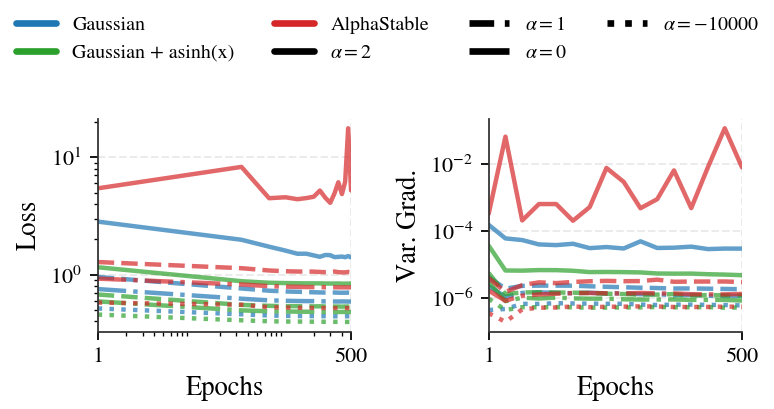

In [7]:
results = copy.deepcopy(raw_results)

fig, axis = plt.subplots(1, 2, figsize=(5.0, 2.5), squeeze=False)

for spec in model_specs:
    avg_loss, avg_grad_var = averaged_grad_curve(results[spec["name"]], n_epochs=n_epochs)
    tt = np.linspace(1, n_epochs, len(avg_loss), dtype=int)
    color, linestyle = curve_style(spec, source_colors=source_colors, loss_ls=loss_ls)
    axis[0, 0].plot(tt, avg_loss, color=color, ls=linestyle, lw=2.0, alpha=0.7)
    axis[0, 1].plot(tt, avg_grad_var, color=color, ls=linestyle, lw=2.0, alpha=0.7)

axis[0, 0].set_xscale("log")
axis[0, 0].set_yscale("log")
axis[0, 0].set_xlim(1, n_epochs)
axis[0, 0].set_xticks([1, n_epochs], ["1", f"{n_epochs}"])
axis[0, 0].set_xlabel("Epochs")
axis[0, 0].set_ylabel("Loss")

axis[0, 1].set_yscale("log")
axis[0, 1].set_xlim(1, n_epochs)
axis[0, 1].set_xticks([1, n_epochs], ["1", f"{n_epochs}"])
axis[0, 1].set_xlabel("Epochs")
axis[0, 1].set_ylabel("Var. Grad.")

legend_handles = [Line2D([0], [0], color=color, lw=3.0, label=source_name)
                  for source_name, color in source_colors.items()]
legend_handles += [Line2D([0], [0], color="black", lw=3.0, ls=loss_ls[alpha_value], label=rf"$\alpha = {fmt_alabel(alpha_value)}$")
                   for alpha_value in barron_alphas]

fig.legend(legend_handles, [handle.get_label() for handle in legend_handles],
           loc="upper center", bbox_to_anchor=(0.5, 1.08), ncol=4, frameon=False,
           fontsize=9)

fig.tight_layout(rect=(0, 0, 1.0, 0.85))


In [8]:
results = copy.deepcopy(raw_results)

rows = []
for i, spec in enumerate(model_specs):

    t0 = time.time()
    print(f"[{i + 1:02d} / {len(model_specs):02d}] {spec['name']}: Metrics computation...", end="")

    result = results[spec["name"]]
    trial_metrics = []
    for trial_idx, trial in enumerate(result["trials"], start=1):
        with torch.no_grad():
            x_gen = trial["generator"].sample(n_samples_test)

        trial_metrics.append({
            "trial": trial_idx,
            "test-MSSLE95": mssle_95(x_gen, x_ref),
            "test-Wass": wasserstein_distance(x_gen, x_ref),
        })

    row = {
        "source_distri": spec["source_distri"],
        "loss": spec["loss"],
        "loss_alpha": spec["loss_alpha"],
        "n_trials": len(trial_metrics),
    }
    for metric_name in ("test-MSSLE95", "test-Wass",):
        values = [trial_metric[metric_name] for trial_metric in trial_metrics]
        row[metric_name] = float(np.mean(values))
        row[f"{metric_name}-std"] = float(np.std(values))

    print(f"Done (in {time.time() - t0:.1f} s).")

    rows.append(row)


[01 / 12] GaussianBarronAlpha2: Metrics computation...Done (in 26.2 s).
[02 / 12] GaussianBarronAlpha1: Metrics computation...Done (in 23.6 s).
[03 / 12] GaussianBarronAlpha0: Metrics computation...Done (in 21.9 s).
[04 / 12] GaussianBarronAlphaneg10000: Metrics computation...Done (in 28.9 s).
[05 / 12] Gaussian_plus_asinh_x_BarronAlpha2: Metrics computation...Done (in 30.2 s).
[06 / 12] Gaussian_plus_asinh_x_BarronAlpha1: Metrics computation...Done (in 36.9 s).
[07 / 12] Gaussian_plus_asinh_x_BarronAlpha0: Metrics computation...Done (in 30.1 s).
[08 / 12] Gaussian_plus_asinh_x_BarronAlphaneg10000: Metrics computation...Done (in 27.4 s).
[09 / 12] AlphaStableBarronAlpha2: Metrics computation...Done (in 19.6 s).
[10 / 12] AlphaStableBarronAlpha1: Metrics computation...Done (in 21.5 s).
[11 / 12] AlphaStableBarronAlpha0: Metrics computation...Done (in 18.6 s).
[12 / 12] AlphaStableBarronAlphaneg10000: Metrics computation...Done (in 21.6 s).


In [9]:
df = pd.DataFrame(rows)
df["source_distri"] = pd.Categorical(df["source_distri"], categories=source_order, ordered=True)
df["loss"] = pd.Categorical(df["loss"], categories=loss_order, ordered=True)
df = df.sort_values(["source_distri", "loss_alpha"]).reset_index(drop=True)

tables = {}
caption_items = {"(a) MSSLE(95)": "test-MSSLE95",
                 "(b) Wasserstein distance": "test-Wass",
                 }
for caption, metric_key in caption_items.items():
    mean_df = df.pivot_table(index="source_distri", columns="loss", values=metric_key,
                             aggfunc="mean", observed=False)
    std_df = df.pivot_table(index="source_distri", columns="loss", values=f"{metric_key}-std",
                            aggfunc="mean", observed=False)
    tables[caption] = {
        "mean": mean_df.reindex(index=source_order, columns=loss_order),
        "std": std_df.reindex(index=source_order, columns=loss_order),
    }


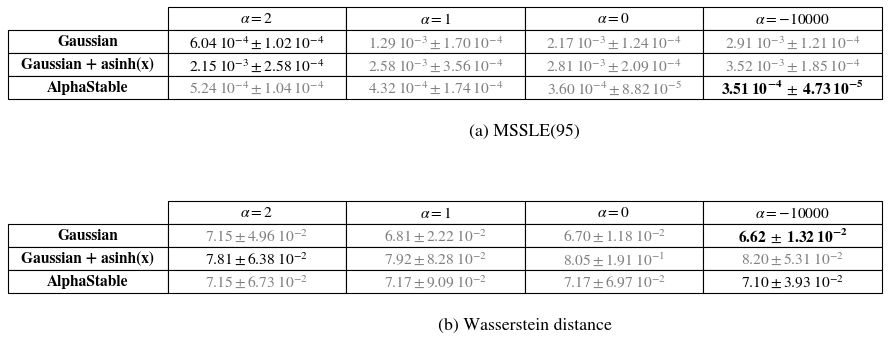

In [10]:
fig, axis = plt.subplots(len(tables), 1, figsize=(1.6 * len(loss_order), 2.6), squeeze=False)

for i, (caption, table_stats) in enumerate(tables.items()):
    axis[i, 0].axis("off")
    mean_df = table_stats["mean"]
    std_df = table_stats["std"]
    row_min_mask = mean_df.eq(mean_df.min(axis=1), axis=0)
    table_min_mask = mean_df.eq(mean_df.min().min())
    formatted = mean_df.copy().astype(object)
    for row_label in mean_df.index:
        for col_label in mean_df.columns:
            mean = mean_df.loc[row_label, col_label]
            std = std_df.loc[row_label, col_label]
            is_best = bool(table_min_mask.loc[row_label, col_label])
            formatted.loc[row_label, col_label] = "-" if pd.isna(mean) else format_mean_std_latex(mean, std, bold=is_best)

    table = axis[i, 0].table(
        cellText=formatted.values,
        rowLabels=formatted.index,
        colLabels=formatted.columns,
        cellLoc="center",
        rowLoc="center",
        loc="center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(7)
    table.scale(1.35, 1.6)

    for (row, col), cell in table.get_celld().items():
        cell.set_linewidth(0.5)
        cell.set_text_props(alpha=0.5)
        if row == 0 or col == -1:
            cell.set_text_props(weight="bold", alpha=1.0)
        elif row > 0 and col >= 0 and row_min_mask.iloc[row - 1, col]:
            cell.set_text_props(alpha=1.0)

    axis[i, 0].text(0.5, -0.4, caption, transform=axis[i, 0].transAxes,
                    ha="center", va="top", fontsize=8)

fig.tight_layout()
